ALGO
AENO
SRNA
ELLT
HUXZ
DUCT
EORC
CUBO
HRET
DIHO
SPLZ
NWIG
MDGI
AGVF
ACAC
SRTX
IHOZ
FWWG
HRND
AETS
BLBT
HTRK
NGTE
MHRM
EAFC
cor_bask:  ['ALGO', 'AENO', 'SRNA', 'ELLT', 'HUXZ', 'DUCT', 'EORC', 'CUBO', 'HRET', 'DIHO', 'SPLZ', 'NWIG', 'MDGI', 'AGVF', 'ACAC', 'SRTX', 'IHOZ', 'FWWG', 'HRND', 'AETS', 'BLBT', 'HTRK', 'NGTE', 'MHRM', 'EAFC']


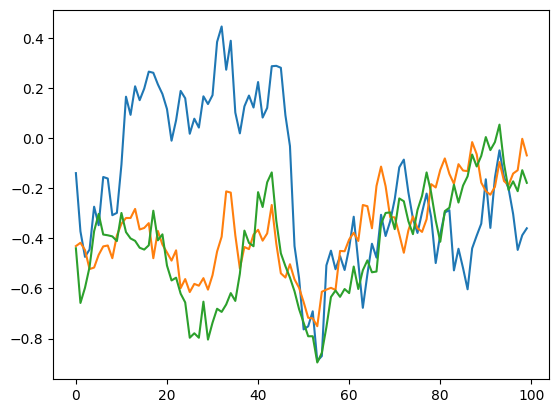

In [56]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

prices = pd.read_csv("prices.txt", sep=r"\s+")
returns = prices.pct_change()
assets = prices.columns.tolist()

algo_prices = prices["ALGO"]

bus = []
correlated_basket = []
for asset in prices:
    corr = np.corrcoef(prices["ALGO"], prices[asset])[0, 1]
    if (abs(corr) > 0.5):
        correlated_basket.append(asset)
        print(asset)
    bus.append(corr)



norm_algo = (prices["ALGO"] - prices['ALGO'].mean())/(prices["ALGO"].std())
norm_eorc = (prices["EORC"] - prices['EORC'].mean())/(prices["EORC"].std())
norm_ngte = (prices["NGTE"] - prices['NGTE'].mean())/(prices["NGTE"].std())

spread = norm_algo - norm_eorc

plt.plot

plt.plot(norm_algo[0:100])
plt.plot(norm_eorc[0:100])
plt.plot(norm_ngte[0:100])

from statsmodels.tsa.stattools import adfuller

series = spread

result = adfuller(series)

adf_stat = result[0]
p_value = result[1]
critical_values = result[4]
print("cor_bask: ", correlated_basket)



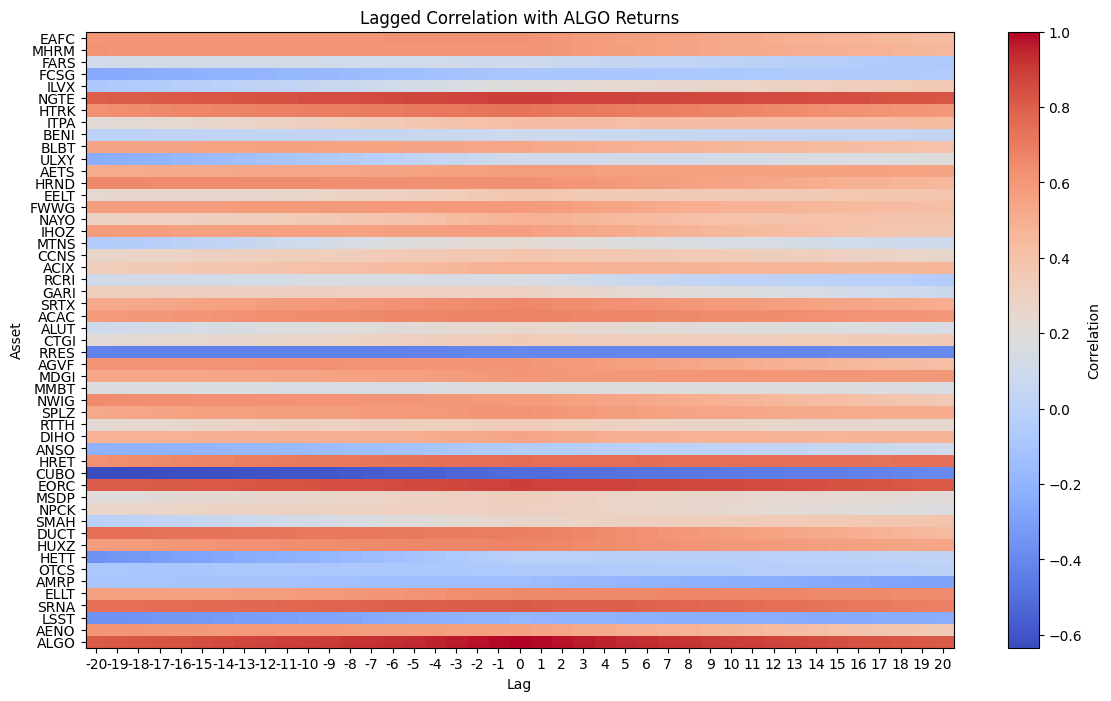

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Compute returns
returns = prices

target = "ALGO"
max_lag = 20

assets = returns.columns
lag_corr = pd.DataFrame(index=assets, columns=range(-max_lag, max_lag + 1))

for asset in assets:
    x = returns[target]
    y = returns[asset]

    for lag in range(-max_lag, max_lag + 1):

        if lag > 0:
            # ALGO leads asset
            corr = x.shift(lag).corr(y)

        elif lag < 0:
            # Asset leads ALGO
            corr = x.corr(y.shift(-lag))

        else:
            corr = x.corr(y)

        lag_corr.loc[asset, lag] = corr

lag_corr = lag_corr.astype(float)

plt.figure(figsize=(14, 8))
plt.imshow(lag_corr, aspect="auto", cmap="coolwarm", origin="lower")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(lag_corr.columns)),
    lag_corr.columns
)
plt.yticks(
    range(len(lag_corr.index)),
    lag_corr.index
)

plt.xlabel("Lag")
plt.ylabel("Asset")
plt.title("Lagged Correlation with ALGO Returns")
plt.show()

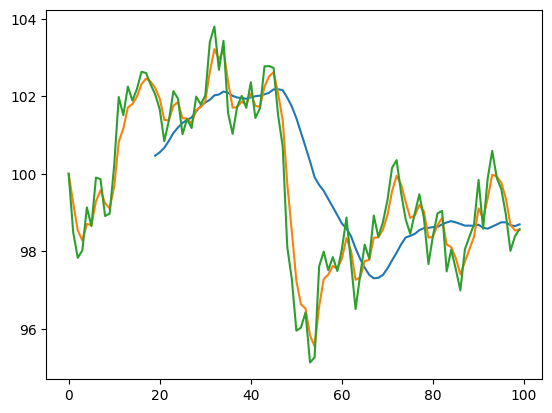

In [40]:
prices = prices[0:100]
s = prices["ALGO"]
ma = s.rolling(window=20).mean().tolist()
ewma = s.ewm(alpha=0.5, adjust=False).mean().tolist()

plt.plot(ma)
plt.plot(ewma)
plt.plot(s)



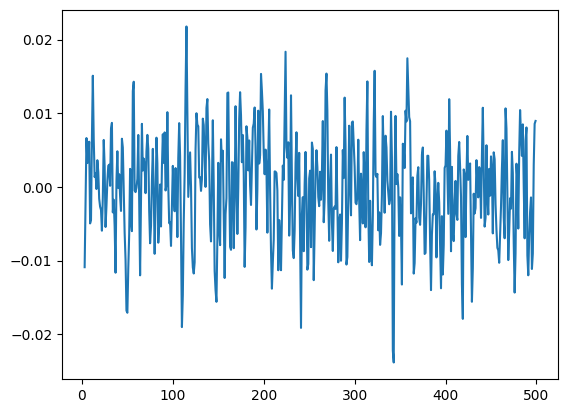

In [52]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

prices = pd.read_csv("prices.txt", sep=r"\s+")
returns = prices.pct_change()

x = 2

ave_returns = returns.shift(1).rolling(x).mean()
std_returns = returns.shift(1).rolling(x).std()

algo_rets = returns["ALGO"]

returns = returns.drop(columns=["ALGO"])
returns.head()

ave_returns = returns.shift(1).rolling(x).mean()
algo_rolling_returns = algo_rets.shift(1).rolling(x).mean()
# std_returns = returns.shift(1).rolling(x).std()

ave_market_returns = row_sums = ave_returns.sum(axis=1)
ave_market_returns.head()

#plt.plot(ave_market_returns)
plt.plot(algo_rolling_returns)






## Standardised ALGO vs Market Rolling Returns

This plot compares ALGO's rolling return against the average non-ALGO market rolling return. The bottom panel shows the relative z-score used by the current ALGO mean-reversion idea: positive means ALGO has recently outperformed the market, negative means ALGO has recently underperformed.

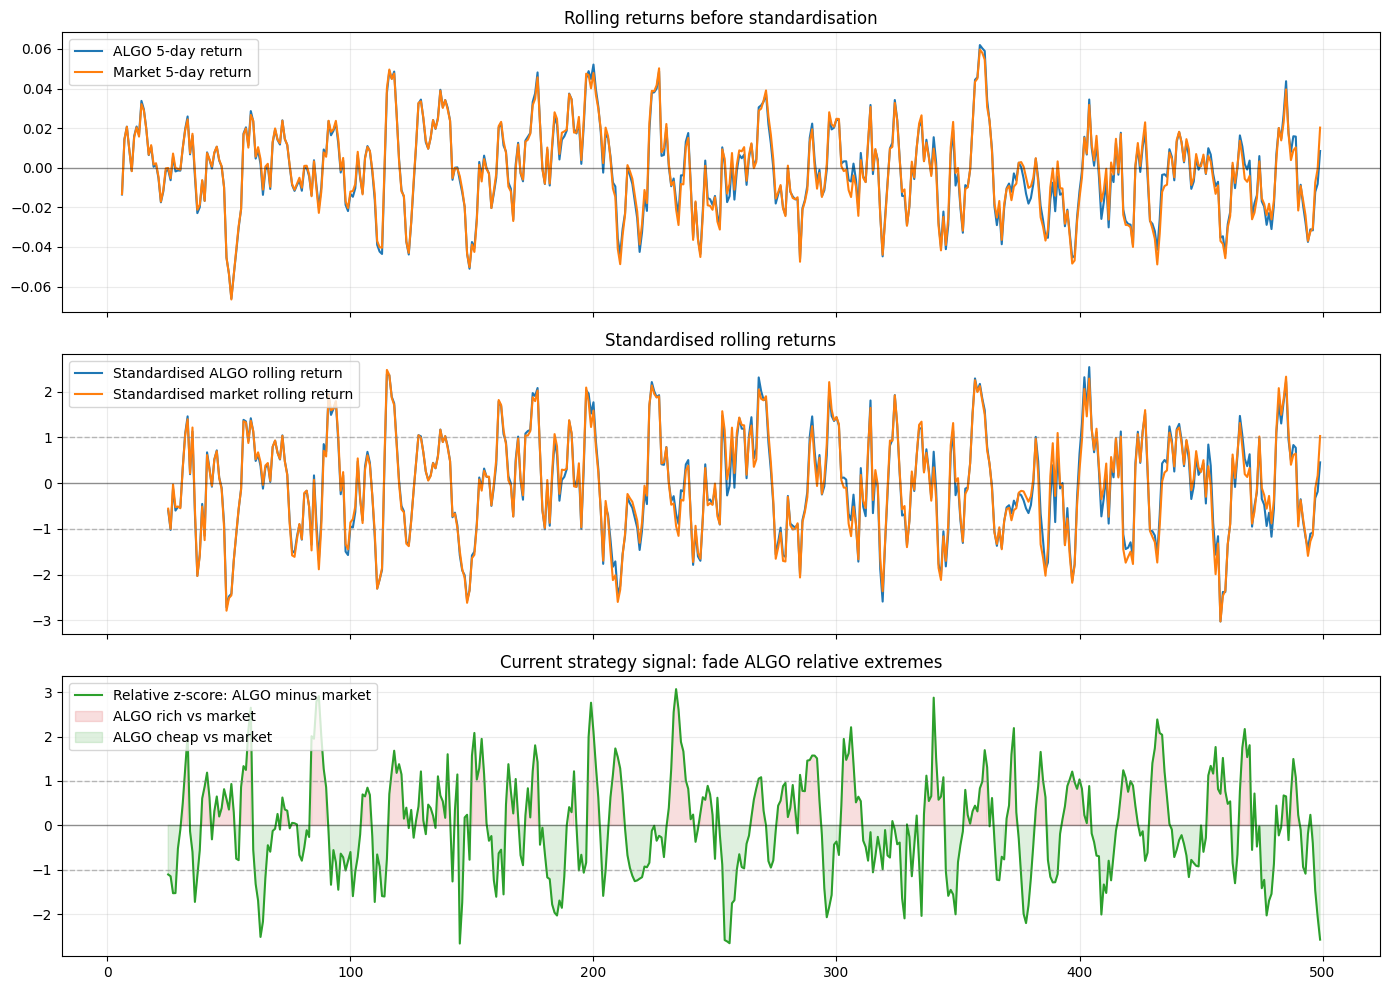

,algo_rolling_return,market_rolling_return,relative_return,relative_z,algo_position_fraction
490,-0.019757,-0.021591,0.001834,0.232792,-0.228676
491,-0.008599,-0.009239,0.000640,-0.099083,0.098760
492,-0.019017,-0.016359,-0.002658,-0.936091,0.733421
493,-0.027601,-0.024036,-0.003565,-1.087715,0.796043
494,-0.037429,-0.036958,-0.000471,-0.189716,0.187472
495,-0.031086,-0.032279,0.001192,0.238369,-0.233955
496,-0.031614,-0.030548,-0.001066,-0.402196,0.381827
497,-0.012232,-0.007409,-0.004823,-1.467464,0.899093
498,-0.008159,-0.000520,-0.007639,-2.062048,0.968159
499,0.008448,0.020262,-0.011814,-2.572742,0.988416


In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("prices.txt", sep=r"\s+")
returns = prices.pct_change()

ROLLING_RETURN_WINDOW = 5
STANDARDISE_WINDOW = 20

target = "ALGO"

# Use yesterday's completed rolling return so the visual matches tradable information.
algo_rolling_return = prices[target].pct_change(ROLLING_RETURN_WINDOW).shift(1)
market_rolling_return = (
    returns.drop(columns=[target])
    .mean(axis=1)
    .rolling(ROLLING_RETURN_WINDOW)
    .sum()
    .shift(1)
)

def rolling_z_score(series, window):
    rolling_mean = series.rolling(window).mean()
    rolling_std = series.rolling(window).std()
    return (series - rolling_mean) / rolling_std.replace(0, np.nan)

algo_z = rolling_z_score(algo_rolling_return, STANDARDISE_WINDOW)
market_z = rolling_z_score(market_rolling_return, STANDARDISE_WINDOW)

relative_return = algo_rolling_return - market_rolling_return
relative_z = rolling_z_score(relative_return, STANDARDISE_WINDOW)
algo_position_fraction = -np.tanh(relative_z)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(algo_rolling_return, label="ALGO 5-day return", color="tab:blue", linewidth=1.5)
axes[0].plot(market_rolling_return, label="Market 5-day return", color="tab:orange", linewidth=1.5)
axes[0].axhline(0, color="black", linewidth=1, alpha=0.4)
axes[0].set_title("Rolling returns before standardisation")
axes[0].legend()
axes[0].grid(True, alpha=0.25)

axes[1].plot(algo_z, label="Standardised ALGO rolling return", color="tab:blue", linewidth=1.5)
axes[1].plot(market_z, label="Standardised market rolling return", color="tab:orange", linewidth=1.5)
axes[1].axhline(0, color="black", linewidth=1, alpha=0.4)
axes[1].axhline(1, color="grey", linestyle="--", linewidth=1, alpha=0.5)
axes[1].axhline(-1, color="grey", linestyle="--", linewidth=1, alpha=0.5)
axes[1].set_title("Standardised rolling returns")
axes[1].legend()
axes[1].grid(True, alpha=0.25)

axes[2].plot(relative_z, label="Relative z-score: ALGO minus market", color="tab:green", linewidth=1.5)
axes[2].fill_between(relative_z.index, 0, relative_z, where=relative_z > 0, color="tab:red", alpha=0.15, label="ALGO rich vs market")
axes[2].fill_between(relative_z.index, 0, relative_z, where=relative_z < 0, color="tab:green", alpha=0.15, label="ALGO cheap vs market")
axes[2].axhline(0, color="black", linewidth=1, alpha=0.4)
axes[2].axhline(1, color="grey", linestyle="--", linewidth=1, alpha=0.5)
axes[2].axhline(-1, color="grey", linestyle="--", linewidth=1, alpha=0.5)
axes[2].set_title("Current strategy signal: fade ALGO relative extremes")
axes[2].legend(loc="upper left")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

signal_table = pd.DataFrame({
    "algo_rolling_return": algo_rolling_return,
    "market_rolling_return": market_rolling_return,
    "relative_return": relative_return,
    "relative_z": relative_z,
    "algo_position_fraction": algo_position_fraction,
})

signal_table.tail(10)


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("prices.txt", sep=r"\s+")
returns = prices.pct_change()

ROLLING_RETURN_WINDOW = 5
STANDARDISE_WINDOW = 20

# Use yesterday's completed rolling return so the visual matches tradable information.
algo_rolling_return = prices["ALGO"].pct_change(ROLLING_RETURN_WINDOW).shift(1)
market_rolling_return = (
    returns.drop(columns=["ALGO"])
    .mean(axis=1)
    .rolling(ROLLING_RETURN_WINDOW)
    .sum()
    .shift(1)
)

def rolling_z_score(series, window):
    rolling_mean = series.rolling(window).mean()
    rolling_std = series.rolling(window).std()
    return (series - rolling_mean) / rolling_std.replace(0, np.nan)

algo_z = rolling_z_score(algo_rolling_return, STANDARDISE_WINDOW)
market_z = rolling_z_score(market_rolling_return, STANDARDISE_WINDOW)

relative_return = algo_rolling_return - market_rolling_return
relative_z = rolling_z_score(relative_return, STANDARDISE_WINDOW)
algo_position_fraction = -np.tanh(relative_z)

cash = 0
cur_cash_pos = 0


state = 0 # 0 if u a bum, 1 if u longing, 2 if u shorting (nathan/siyath/gourab height)

# 0 -> 1, 0->2
# 1->0, 1->2
# 2->0, 2->1

for i in range(len(prices) - ROLLING_RETURN_WINDOW - STANDARDISE_WINDOW):
    index = i + STANDARDISE_WINDOW + ROLLING_RETURN_WINDOW
    if relative_z[index] > 2:
        pos_taken = min(POSITION_LIMIT*algo_position_fraction[index], POSITION_LIMIT - cur_pos*prices['ALGO'].iloc[index])
        cash -= 



25


## Threshold ALGO Relative-Reversion Backtest

This finishes the state-transition idea from the previous cell. The strategy enters a max long/short ALGO position only when the relative z-score crosses an entry threshold, then holds that state until the z-score mean-reverts through an exit threshold.

,entry_z,exit_z,train_sharpe,train_score,train_return,train_total_pl,test_sharpe,test_score,test_return,test_total_pl
0,1.25,0.75,1.863588,49.044257,0.003053,23371.419801,3.753650,120.543639,0.007492,12909.896902
1,0.75,0.25,1.339749,43.630034,0.002126,25136.858836,2.261052,82.370944,0.003609,9848.307591
2,1.25,0.25,1.552418,42.829867,0.003258,22422.582810,3.689568,127.146210,0.008960,13648.632988
3,0.50,0.25,1.278656,42.291433,0.001934,25218.597459,2.223031,87.317940,0.002812,10498.696231
4,1.00,0.75,1.563002,42.229097,0.002045,22020.558222,2.919571,101.903323,0.004506,11385.834213
5,1.25,0.50,1.492115,38.653603,0.003014,20725.562315,3.669180,119.376761,0.008414,12824.386503
6,1.25,1.00,1.663808,38.415107,0.002532,19348.076933,3.179500,95.807785,0.006127,10528.505087
7,1.25,0.00,1.231651,31.866404,0.002755,19563.041958,4.220631,150.577119,0.010438,15902.999087
8,0.50,0.00,1.044534,31.756868,0.001927,22519.507445,2.209501,96.082004,0.003677,11576.329279
9,0.75,0.50,1.133139,31.161262,0.001653,20509.125862,2.105419,71.812229,0.003224,8801.246651


Best training threshold: entry_z=1.25, exit_z=0.75


,train,test
mean_pl,6.316600e+01,1.290990e+02
std_pl,5.359243e+02,5.437998e+02
annualised_sharpe,1.863588e+00,3.753650e+00
score,4.904426e+01,1.205436e+02
total_pl,2.337142e+04,1.290990e+04
final_value,2.337142e+04,1.290990e+04
dollar_volume,7.654010e+06,1.723155e+06
eval_style_return,3.053487e-03,7.492012e-03


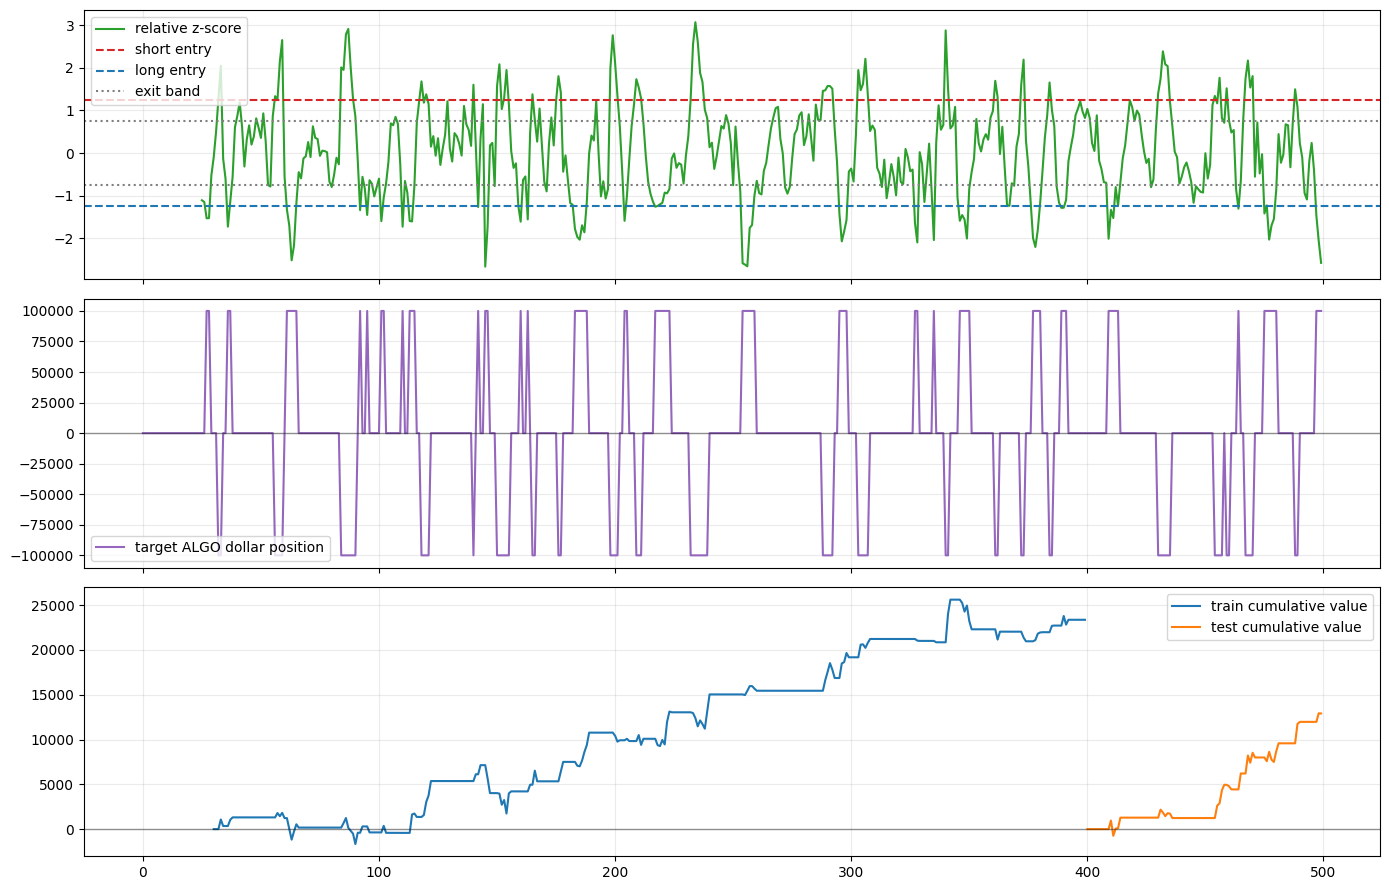

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("prices.txt", sep=r"\s+")
returns = prices.pct_change()

TARGET = "ALGO"
ROLLING_RETURN_WINDOW = 5
STANDARDISE_WINDOW = 20
POSITION_LIMIT = 100_000
COMMISSION_RATE = 0.00002
TRAIN_END = 400
TEST_START = 400

algo_price = prices[TARGET]

# Signal at day t uses returns completed up to t-1, so it can be traded at day t.
algo_rolling_return = algo_price.pct_change(ROLLING_RETURN_WINDOW).shift(1)
market_rolling_return = (
    returns.drop(columns=[TARGET])
    .mean(axis=1)
    .rolling(ROLLING_RETURN_WINDOW)
    .sum()
    .shift(1)
)

def rolling_z_score(series, window):
    rolling_mean = series.rolling(window).mean()
    rolling_std = series.rolling(window).std()
    return (series - rolling_mean) / rolling_std.replace(0, np.nan)

relative_return = algo_rolling_return - market_rolling_return
relative_z = rolling_z_score(relative_return, STANDARDISE_WINDOW)


def score_function(mean_pl, std_pl):
    if mean_pl <= 0 or std_pl < 1e-10:
        return mean_pl
    sharpe = np.sqrt(250) * mean_pl / std_pl
    return mean_pl * (sharpe**2 / (sharpe**2 + 1))


def performance_summary(daily_pl, final_value, total_dollar_volume):
    daily_pl = pd.Series(daily_pl).replace([np.inf, -np.inf], np.nan).dropna()
    mean_pl = daily_pl.mean()
    std_pl = daily_pl.std(ddof=0)
    sharpe = 0.0 if std_pl <= 0 else np.sqrt(250) * mean_pl / std_pl
    return pd.Series({
        "mean_pl": mean_pl,
        "std_pl": std_pl,
        "annualised_sharpe": sharpe,
        "score": score_function(mean_pl, std_pl),
        "total_pl": daily_pl.sum(),
        "final_value": final_value,
        "dollar_volume": total_dollar_volume,
        "eval_style_return": 0.0 if total_dollar_volume <= 0 else final_value / total_dollar_volume,
    })


def threshold_positions(relative_z, entry_z=1.0, exit_z=0.25):
    state = 0
    states = []

    for z in relative_z:
        if not np.isfinite(z):
            states.append(state)
            continue

        if state == 0:
            if z >= entry_z:
                state = -1       # ALGO rich vs market: short ALGO
            elif z <= -entry_z:
                state = 1        # ALGO cheap vs market: long ALGO

        elif state == 1:
            if z >= entry_z:
                state = -1       # cheap flipped all the way to rich
            elif z >= -exit_z:
                state = 0        # cheapness has mostly mean-reverted

        elif state == -1:
            if z <= -entry_z:
                state = 1        # rich flipped all the way to cheap
            elif z <= exit_z:
                state = 0        # richness has mostly mean-reverted

        states.append(state)

    return pd.Series(states, index=relative_z.index, name="state")


def backtest_threshold(entry_z=1.0, exit_z=0.25, start_day=30, end_day=None):
    if end_day is None:
        end_day = len(prices) - 1

    states = threshold_positions(relative_z, entry_z=entry_z, exit_z=exit_z)
    target_dollars = states * POSITION_LIMIT
    target_shares = (target_dollars / algo_price).replace([np.inf, -np.inf], np.nan).fillna(0).astype(int)

    cash = 0.0
    current_shares = 0
    value = 0.0
    previous_commission = 0.0
    total_dollar_volume = 0.0
    daily_pl = []
    value_path = []

    for t in range(start_day, end_day + 1):
        price = algo_price.iloc[t]
        new_shares = int(target_shares.iloc[t])
        max_shares = int(POSITION_LIMIT / price)
        new_shares = int(np.clip(new_shares, -max_shares, max_shares))

        delta = new_shares - current_shares ## since new_shares can only be the like max position therefore takes care of position limits
        cash -= price * delta + previous_commission

        dollar_volume = abs(delta) * price
        total_dollar_volume += dollar_volume
        previous_commission = dollar_volume * COMMISSION_RATE

        current_shares = new_shares
        new_value = cash + current_shares * price
        daily_pl.append(new_value - value)
        value_path.append(new_value)
        value = new_value

    daily_pl = pd.Series(daily_pl, index=range(start_day, end_day + 1))
    value_path = pd.Series(value_path, index=range(start_day, end_day + 1))
    summary = performance_summary(daily_pl, value, total_dollar_volume)
    return summary, daily_pl, value_path, states

# Sweep entry/exit thresholds using training data only.
rows = []
for entry_z in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    for exit_z in [0.0, 0.25, 0.5, 0.75, 1.0]:
        if exit_z >= entry_z:
            continue
        train_summary, _, _, _ = backtest_threshold(entry_z, exit_z, start_day=30, end_day=TRAIN_END - 1)
        test_summary, _, _, _ = backtest_threshold(entry_z, exit_z, start_day=TEST_START, end_day=len(prices) - 1)
        rows.append({
            "entry_z": entry_z,
            "exit_z": exit_z,
            "train_sharpe": train_summary["annualised_sharpe"],
            "train_score": train_summary["score"],
            "train_return": train_summary["eval_style_return"],
            "train_total_pl": train_summary["total_pl"],
            "test_sharpe": test_summary["annualised_sharpe"],
            "test_score": test_summary["score"],
            "test_return": test_summary["eval_style_return"],
            "test_total_pl": test_summary["total_pl"],
        })

threshold_results = pd.DataFrame(rows).sort_values("train_score", ascending=False).reset_index(drop=True)
display(threshold_results)

best = threshold_results.iloc[0]
print(f"Best training threshold: entry_z={best['entry_z']}, exit_z={best['exit_z']}")

best_train_summary, best_train_pl, best_train_value, best_states = backtest_threshold(
    best["entry_z"], best["exit_z"], start_day=30, end_day=TRAIN_END - 1
)
best_test_summary, best_test_pl, best_test_value, _ = backtest_threshold(
    best["entry_z"], best["exit_z"], start_day=TEST_START, end_day=len(prices) - 1
)

summary_table = pd.DataFrame({
    "train": best_train_summary,
    "test": best_test_summary,
})
display(summary_table)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(relative_z, label="relative z-score", color="tab:green")
axes[0].axhline(best["entry_z"], color="tab:red", linestyle="--", label="short entry")
axes[0].axhline(-best["entry_z"], color="tab:blue", linestyle="--", label="long entry")
axes[0].axhline(best["exit_z"], color="grey", linestyle=":", label="exit band")
axes[0].axhline(-best["exit_z"], color="grey", linestyle=":")
axes[0].legend()
axes[0].grid(True, alpha=0.25)

axes[1].plot(best_states * POSITION_LIMIT, label="target ALGO dollar position", color="tab:purple")
axes[1].axhline(0, color="black", linewidth=1, alpha=0.4)
axes[1].legend()
axes[1].grid(True, alpha=0.25)

best_train_value.plot(ax=axes[2], label="train cumulative value")
best_test_value.plot(ax=axes[2], label="test cumulative value")
axes[2].axhline(0, color="black", linewidth=1, alpha=0.4)
axes[2].legend()
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

